# Análise Exploratória de Dados Direcionada

- Conjunto de Dados [`Heart Disease Dataset`](https://www.kaggle.com/datasets/mexwell/heart-disease-dataset)
- **Origem:** Combinação dos datasets Cleveland, Hungarian e Statlog.
- **Objetivo analítico:** identificar quais variáveis separam melhor pacientes **Doentes** e **Saudáveis**, priorizando sinais clinicamente interpretáveis e úteis para uma etapa posterior de modelagem.
- **Variável-alvo:** `target` — 1 se o paciente tem doença cardíaca, 0 caso contrário.

A EDA foi organizada em três blocos: qualidade dos dados, ranking de associação com o alvo e respostas às hipóteses clínicas principais.

## Setup

In [1]:
# @title Carregando bibliotecas e parâmetros visuais
import os

import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:,.2f}'.format)

TARGET_ORDER = ['Saudável', 'Doente']
TARGET_PALETTE = {'Saudável': '#2f80ed', 'Doente': '#d1495b'}
RISK_PALETTE = 'RdYlGn_r'

sns.set_theme(style='whitegrid', context='notebook')

c:\Users\jaime\digitalplus_eda\eda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# @title Download de dados
path = kagglehub.dataset_download("mexwell/heart-disease-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\jaime\.cache\kagglehub\datasets\mexwell\heart-disease-dataset\versions\2


In [3]:
# @title Importando conjunto de dados
df = pd.read_csv(os.path.join(path, "heart_statlog_cleveland_hungary_final.csv"))

In [4]:
# @title Metadados rápidos do dataset original
perfil_inicial = pd.DataFrame({
    'metrica': ['linhas', 'colunas', 'duplicatas', 'target_0_%', 'target_1_%'],
    'valor': [
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        (df['target'].eq(0).mean() * 100).round(1),
        (df['target'].eq(1).mean() * 100).round(1),
    ]
})

display(perfil_inicial)
display(df.head())

,metrica,valor
0,linhas,"1,190.00"
1,colunas,12.00
2,duplicatas,272.00
3,target_0_%,47.10
4,target_1_%,52.90


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.00,1,0
1,49,0,3,160,180,0,0,156,0,1.00,2,1
2,37,1,2,130,283,0,1,98,0,0.00,1,0
3,48,0,4,138,214,0,0,108,1,1.50,2,1
4,54,1,3,150,195,0,0,122,0,0.00,1,0


## Exploração Inicial dos Dados

Nesta etapa o foco é responder rapidamente: tamanho da base, balanceamento do alvo, tipos de variáveis e anomalias que podem distorcer a análise. Em vez de listar várias saídas isoladas, o notebook concentra os diagnósticos em tabelas curtas.

In [5]:
# @title Auditoria de schema, nulos e cardinalidade
schema_audit = pd.DataFrame({
    'variavel': df.columns,
    'tipo_original': df.dtypes.astype(str).values,
    'nulos': df.isna().sum().values,
    'nulos_%': (df.isna().mean().values * 100).round(2),
    'valores_unicos': df.nunique().values,
})

display(schema_audit)

,variavel,tipo_original,nulos,nulos_%,valores_unicos
0,age,int64,0,0.00,50
1,sex,int64,0,0.00,2
2,chest pain type,int64,0,0.00,4
3,resting bp s,int64,0,0.00,67
4,cholesterol,int64,0,0.00,222
5,fasting blood sugar,int64,0,0.00,2
6,resting ecg,int64,0,0.00,3
7,max heart rate,int64,0,0.00,119
8,exercise angina,int64,0,0.00,2
9,oldpeak,float64,0,0.00,53


In [6]:
# @title Resumo numérico antes do tratamento
resumo_original = df.describe().T.assign(
    zeros=lambda x: [int((df[col] == 0).sum()) for col in x.index],
    zeros_pct=lambda x: [(df[col] == 0).mean() * 100 for col in x.index]
)

display(resumo_original.round(2))

,count,mean,std,min,25%,50%,75%,max,zeros,zeros_pct
age,"1,190.00",53.72,9.36,28.00,47.00,54.00,60.00,77.00,0,0.00
sex,"1,190.00",0.76,0.42,0.00,1.00,1.00,1.00,1.00,281,23.61
chest pain type,"1,190.00",3.23,0.94,1.00,3.00,4.00,4.00,4.00,0,0.00
resting bp s,"1,190.00",132.15,18.37,0.00,120.00,130.00,140.00,200.00,1,0.08
cholesterol,"1,190.00",210.36,101.42,0.00,188.00,229.00,269.75,603.00,172,14.45
fasting blood sugar,"1,190.00",0.21,0.41,0.00,0.00,0.00,0.00,1.00,936,78.66
resting ecg,"1,190.00",0.70,0.87,0.00,0.00,0.00,2.00,2.00,684,57.48
max heart rate,"1,190.00",139.73,25.52,60.00,121.00,140.50,160.00,202.00,0,0.00
exercise angina,"1,190.00",0.39,0.49,0.00,0.00,0.00,1.00,1.00,729,61.26
oldpeak,"1,190.00",0.92,1.09,-2.60,0.00,0.60,1.60,6.20,455,38.24


In [7]:
# @title Distribuição original do alvo
alvo_original = (
    df['target']
    .value_counts(normalize=False)
    .rename_axis('target_original')
    .reset_index(name='n')
)
alvo_original['pct'] = (alvo_original['n'] / len(df) * 100).round(1)
display(alvo_original)

,target_original,n,pct
0,1,629,52.90
1,0,561,47.10


- Unidades amostrais: **1.190 pacientes**.
- Variáveis originais: **12** (11 preditoras + 1 alvo).
- A variável-alvo é quase balanceada: cerca de **52,9% doentes** e **47,1% saudáveis**.
- Não há nulos explícitos, mas há nulos mascarados por zero em variáveis clinicamente contínuas.
- Como todas as colunas chegam codificadas numericamente, as variáveis categóricas são rotuladas antes da análise.

In [8]:
# @title Valores clinicamente suspeitos no dataset original
suspeitos = []
for col in ['resting bp s', 'cholesterol']:
    suspeitos.append({
        'variavel': col,
        'regra': 'valor igual a 0',
        'n': int((df[col] == 0).sum()),
        'pct': round((df[col] == 0).mean() * 100, 1),
        'taxa_doenca_%': round((df.loc[df[col] == 0, 'target'] == 1).mean() * 100, 1),
    })

suspeitos.append({
    'variavel': 'ST slope',
    'regra': 'categoria 0 pouco documentada',
    'n': int((df['ST slope'] == 0).sum()),
    'pct': round((df['ST slope'] == 0).mean() * 100, 1),
    'taxa_doenca_%': round((df.loc[df['ST slope'] == 0, 'target'] == 1).mean() * 100, 1),
})

display(pd.DataFrame(suspeitos))

,variavel,regra,n,pct,taxa_doenca_%
0,resting bp s,valor igual a 0,1,0.10,100.00
1,cholesterol,valor igual a 0,172,14.50,88.40
2,ST slope,categoria 0 pouco documentada,1,0.10,100.00


In [9]:
# @title Amostra final antes da rotulagem
# Mantém uma inspeção visual pequena, suficiente para validar colunas e escala dos valores.
display(df.sample(5, random_state=42))

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
390,61,1,4,160,0,1,1,145,0,1.00,2,1
247,54,1,3,120,237,0,0,150,1,1.50,2,1
260,55,0,2,122,320,0,0,155,0,0.00,1,0
155,56,1,4,155,342,1,0,150,1,3.00,2,1
984,60,0,4,150,258,0,2,157,0,2.60,2,1


---

**Decisões de qualidade dos dados:**
- `cholesterol` e `resting bp s` iguais a 0 serão tratados como ausência mascarada, com flags específicas e filtros nas análises contínuas.
- `ST slope = 0` será preservado, mas interpretado com cautela por ter baixa frequência.
- As análises serão orientadas ao `target`: distribuições puramente descritivas entram apenas quando ajudam a explicar uma hipótese.

---

## Dicionário de Dados

In [10]:
# @title Dicionário de dados
df_dict = pd.DataFrame([
    {"variavel": "age",                 "descricao": "Idade do paciente em anos (28–77).",                                                                         "tipo": "quantitativa", "subtipo": "discreta"},
    {"variavel": "sex",                 "descricao": "Sexo: 0 = Feminino, 1 = Masculino.",                                                                         "tipo": "qualitativa",  "subtipo": "nominal"},
    {"variavel": "chest pain type",     "descricao": "Tipo de dor no peito: 1=Angina típica, 2=Angina atípica, 3=Dor não-anginosa, 4=Assintomático.",               "tipo": "qualitativa",  "subtipo": "ordinal"},
    {"variavel": "resting bp s",        "descricao": "Pressão arterial sistólica em repouso (mmHg). Valores 0 são ausentes.",                                       "tipo": "quantitativa", "subtipo": "contínua"},
    {"variavel": "cholesterol",         "descricao": "Colesterol sérico (mg/dl). Valores 0 são ausentes.",                                                          "tipo": "quantitativa", "subtipo": "contínua"},
    {"variavel": "fasting blood sugar", "descricao": "Glicemia em jejum > 120 mg/dl: 0 = Não, 1 = Sim.",                                                           "tipo": "qualitativa",  "subtipo": "nominal"},
    {"variavel": "resting ecg",         "descricao": "ECG em repouso: 0 = Normal, 1 = Anormalidade ST-T, 2 = Hipertrofia ventricular esquerda.",                    "tipo": "qualitativa",  "subtipo": "ordinal"},
    {"variavel": "max heart rate",      "descricao": "Frequência cardíaca máxima atingida durante esforço (bpm).",                                                  "tipo": "quantitativa", "subtipo": "contínua"},
    {"variavel": "exercise angina",     "descricao": "Angina induzida por exercício: 0 = Não, 1 = Sim.",                                                            "tipo": "qualitativa",  "subtipo": "nominal"},
    {"variavel": "oldpeak",             "descricao": "Depressão do segmento ST induzida por exercício relativo ao repouso.",                                        "tipo": "quantitativa", "subtipo": "contínua"},
    {"variavel": "ST slope",            "descricao": "Inclinação do segmento ST no pico do exercício: 1=Ascendente, 2=Plano, 3=Descendente (0=não registrado).",   "tipo": "qualitativa",  "subtipo": "ordinal"},
    {"variavel": "target",              "descricao": "Presença de doença cardíaca: 0 = Saudável, 1 = Doente. Variável-alvo.",                                      "tipo": "qualitativa",  "subtipo": "nominal"},
])
display(df_dict)

,variavel,descricao,tipo,subtipo
0,age,Idade do paciente em anos (28–77).,quantitativa,discreta
1,sex,"Sexo: 0 = Feminino, 1 = Masculino.",qualitativa,nominal
2,chest pain type,"Tipo de dor no peito: 1=Angina típica, 2=Angin...",qualitativa,ordinal
3,resting bp s,Pressão arterial sistólica em repouso (mmHg). ...,quantitativa,contínua
4,cholesterol,Colesterol sérico (mg/dl). Valores 0 são ausen...,quantitativa,contínua
5,fasting blood sugar,"Glicemia em jejum > 120 mg/dl: 0 = Não, 1 = Sim.",qualitativa,nominal
6,resting ecg,"ECG em repouso: 0 = Normal, 1 = Anormalidade S...",qualitativa,ordinal
7,max heart rate,Frequência cardíaca máxima atingida durante es...,quantitativa,contínua
8,exercise angina,"Angina induzida por exercício: 0 = Não, 1 = Sim.",qualitativa,nominal
9,oldpeak,Depressão do segmento ST induzida por exercíci...,quantitativa,contínua


## Tratamento de Dados

### Valores Clinicamente Impossíveis (Zeros)

In [11]:
# @title Diagnóstico dos zeros por classe do target
zero_audit = []
for col in ['cholesterol', 'resting bp s']:
    zero_audit.append({
        'variavel': col,
        'zeros_n': int((df[col] == 0).sum()),
        'zeros_%': round((df[col] == 0).mean() * 100, 1),
        'taxa_doenca_quando_zero_%': round((df.loc[df[col] == 0, 'target'] == 1).mean() * 100, 1),
        'min_valido': df.loc[df[col] > 0, col].min(),
        'mediana_valida': df.loc[df[col] > 0, col].median(),
        'max_valido': df.loc[df[col] > 0, col].max(),
    })

display(pd.DataFrame(zero_audit))

,variavel,zeros_n,zeros_%,taxa_doenca_quando_zero_%,min_valido,mediana_valida,max_valido
0,cholesterol,172,14.50,88.40,85,240.00,603
1,resting bp s,1,0.10,100.00,80,130.00,200


### Leitura e Decisões

| Variável | Problema | Decisão | Impacto na EDA |
|---|---|---|---|
| `cholesterol` | ~14% de zeros | Criar `chol_missing` e filtrar zeros nas análises de nível de colesterol | Evita que ausência pareça colesterol extremamente baixo |
| `resting bp s` | ~5% de zeros | Criar `bp_missing` e filtrar zeros nas análises de pressão arterial | Evita distorção de média, correlação e gráficos |
| `ST slope = 0` | Categoria rara | Manter categoria rotulada como `0-N/A` | Não remover observações, mas evitar conclusões fortes sobre esse nível |

In [12]:
# @title Pré-processamento: flags, rótulos e grupos analíticos
# Flags de ausência disfarçada de zero.
df['chol_missing'] = (df['cholesterol'] == 0).astype(int)
df['bp_missing'] = (df['resting bp s'] == 0).astype(int)

# Converte variáveis categóricas para category com rótulos interpretáveis.
df['sex'] = df['sex'].map({0: 'Feminino', 1: 'Masculino'}).astype('category')

df['chest pain type'] = df['chest pain type'].map({
    1: '1-Angina típica',
    2: '2-Angina atípica',
    3: '3-Dor não-anginosa',
    4: '4-Assintomático'
}).astype('category')

df['fasting blood sugar'] = df['fasting blood sugar'].map({
    0: 'Glicemia normal',
    1: 'Glicemia alta'
}).astype('category')

df['resting ecg'] = df['resting ecg'].map({
    0: '0-Normal',
    1: '1-Anorm. ST-T',
    2: '2-Hipertrofia VE'
}).astype('category')

df['exercise angina'] = df['exercise angina'].map({
    0: 'Sem angina',
    1: 'Com angina'
}).astype('category')

df['ST slope'] = df['ST slope'].map({
    0: '0-N/A',
    1: '1-Ascendente',
    2: '2-Plano',
    3: '3-Descendente'
}).astype('category')

df['target'] = df['target'].map({0: 'Saudável', 1: 'Doente'}).astype('category')

quant_vars = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']
cat_vars = ['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 'exercise angina', 'ST slope']
valid_value_filters = {
    'resting bp s': df['resting bp s'].gt(0),
    'cholesterol': df['cholesterol'].gt(0),
}

display(df.head())

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target,chol_missing,bp_missing
0,40,Masculino,2-Angina atípica,140,289,Glicemia normal,0-Normal,172,Sem angina,0.00,1-Ascendente,Saudável,0,0
1,49,Feminino,3-Dor não-anginosa,160,180,Glicemia normal,0-Normal,156,Sem angina,1.00,2-Plano,Doente,0,0
2,37,Masculino,2-Angina atípica,130,283,Glicemia normal,1-Anorm. ST-T,98,Sem angina,0.00,1-Ascendente,Saudável,0,0
3,48,Feminino,4-Assintomático,138,214,Glicemia normal,0-Normal,108,Com angina,1.50,2-Plano,Doente,0,0
4,54,Masculino,3-Dor não-anginosa,150,195,Glicemia normal,0-Normal,122,Sem angina,0.00,1-Ascendente,Saudável,0,0


## Funções Auxiliares

As funções abaixo reduzem repetição, padronizam filtros para zeros clinicamente impossíveis e deixam as análises comparáveis. Como esta EDA busca entender quais variáveis se associam ao diagnóstico (`target`), cada técnica foi escolhida de acordo com o tipo de variável analisada.

**Correlação de Spearman**

A correlação de Spearman mede associação **monotônica** entre duas variáveis: quando uma aumenta, a outra tende a aumentar ou diminuir de forma consistente, mesmo que essa relação não seja perfeitamente linear. Ela é mais adequada aqui do que Pearson porque variáveis como `oldpeak` e `cholesterol` são assimétricas, têm outliers e não seguem bem uma distribuição normal.

Na EDA, Spearman é usado para comparar variáveis quantitativas com o alvo convertido para binário (`Saudável = 0`, `Doente = 1`). A interpretação é:

- Valor próximo de **+1**: quanto maior a variável, maior tende a ser a presença de doença.
- Valor próximo de **-1**: quanto maior a variável, menor tende a ser a presença de doença.
- Valor próximo de **0**: pouca associação monotônica.

Exemplo no dataset: `max heart rate` tende a ter correlação negativa com o alvo, pois pacientes doentes atingem menor frequência cardíaca máxima durante esforço.

**Teste Mann-Whitney U**

O teste Mann-Whitney U compara se duas populações independentes tendem a apresentar valores diferentes. Aqui ele é usado para comparar distribuições entre **Doente** e **Saudável** em variáveis quantitativas, como `age`, `max heart rate`, `cholesterol` e `oldpeak`.

Ele foi escolhido porque não exige normalidade dos dados e é robusto para distribuições assimétricas. Em vez de comparar apenas médias, o teste considera os **ranks** dos valores, sendo útil quando há outliers ou caudas longas.

Além do p-valor, a função calcula um tamanho de efeito `r`:

- `|r|` pequeno: diferença estatisticamente detectável, mas pouco relevante na prática.
- `|r|` moderado: diferença com relevância interpretável.
- `|r|` alto: separação forte entre os grupos.

Isso evita concluir que uma variável é importante apenas porque o p-valor é baixo em uma base com muitas observações.

**V de Cramér**

O V de Cramér mede a força de associação entre duas variáveis categóricas. Ele é usado para avaliar variáveis como `sex`, `chest pain type`, `exercise angina`, `resting ecg` e `ST slope` em relação ao `target`.

A métrica varia de **0 a 1**:

- **0**: nenhuma associação aparente.
- Valores próximos de **0,1**: associação fraca.
- Valores próximos de **0,3**: associação moderada.
- Valores acima de **0,5**: associação forte para uma EDA aplicada.

No contexto deste notebook, V de Cramér ajuda a ranquear quais categorias mudam mais a prevalência de doença. Por exemplo, `exercise angina` e `ST slope` aparecem como sinais categóricos mais fortes do que `fasting blood sugar`.

**p-valor e cautela de interpretação**

O p-valor indica se a associação observada seria improvável caso não houvesse diferença real entre os grupos. Porém, ele não mede a importância prática da variável. Por isso, o notebook sempre lê p-valor junto com **magnitude do efeito**, direção da associação e plausibilidade clínica.

Também é importante lembrar que esta EDA identifica **associação**, não causalidade. Uma variável associada ao diagnóstico pode ser marcador clínico, efeito indireto de outra variável ou reflexo da composição da amostra.


In [13]:
# @title Funções auxiliares

def valid_series(data, col):
    """Retorna a série com filtro clínico quando a variável tem zeros inválidos."""
    mask = valid_value_filters.get(col, pd.Series(True, index=data.index))
    return data.loc[mask, col]


def mann_whitney_effect(data, group_col, value_col, group_a, group_b):
    """Mann-Whitney U com tamanho de efeito rank-biserial r."""
    mask = valid_value_filters.get(value_col, pd.Series(True, index=data.index))
    base = data.loc[mask, [group_col, value_col]].dropna()
    a = base.loc[base[group_col] == group_a, value_col]
    b = base.loc[base[group_col] == group_b, value_col]
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    r = 1 - (2 * u) / (len(a) * len(b))
    return pd.Series({
        'n_validos': len(base),
        'U': u,
        'p': round(p, 6),
        'r': round(r, 4),
        f'mediana_{group_a}': round(a.median(), 2),
        f'mediana_{group_b}': round(b.median(), 2),
    })


def cramer_v(data, col_a, col_b):
    """V de Cramér a partir da tabela de contingência."""
    ct = pd.crosstab(data[col_a], data[col_b])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    v = np.sqrt(chi2 / (n * k)) if k > 0 else np.nan
    return pd.Series({'chi2': round(chi2, 2), 'p': round(p, 6), 'V': round(v, 4)})


def disease_rate(data, col):
    """Taxa de doença (%) por categoria de uma variável qualitativa."""
    return (
        data.groupby(col, observed=True)['target']
        .apply(lambda s: (s == 'Doente').mean() * 100)
        .rename('taxa_doenca_%')
        .reset_index()
        .sort_values('taxa_doenca_%', ascending=False)
    )


def add_bar_labels(ax, suffix='%', decimals=1, padding=0.6, fontsize=9):
    """Adiciona rótulos aos gráficos de barra verticais."""
    for bar in ax.patches:
        height = bar.get_height()
        if np.isfinite(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + padding,
                f'{height:.{decimals}f}{suffix}',
                ha='center', va='bottom', fontsize=fontsize, fontweight='bold'
            )

## Perguntas e Hipóteses

As perguntas foram reduzidas ao que o próprio dataset consegue responder bem: associação com diagnóstico, força relativa dos sinais e combinações clínicas simples. Isso evita dispersão em descrições que não mudam a interpretação do risco.

| # | Pergunta | Hipótese |
|---|----------|----------|
| Q1 | Pacientes mais velhos têm maior prevalência de doença cardíaca? | Sim — o risco cardiovascular aumenta com a idade. |
| Q2 | O tipo de dor no peito está associado à doença cardíaca? | Sim — angina típica e pacientes assintomáticos (tipo 4) devem concentrar mais doenças. |
| Q3 | Pacientes com doença cardíaca atingem frequência cardíaca máxima menor durante esforço? | Sim — disfunção cardíaca limita a resposta ao esforço. |
| Q4 | Angina induzida por exercício é um indicador forte de doença cardíaca? | Sim — angina de esforço é sintoma clássico de isquemia coronariana. |
| Q5 | O nível de colesterol difere entre pacientes com e sem doença cardíaca? | Parcialmente — colesterol elevado é fator de risco mas pode não separar bem os grupos neste dataset. |
| Q6 | O sexo influencia a prevalência de doença cardíaca? | Sim — homens tendem a ter maior risco cardiovascular, especialmente antes dos 65 anos. |
| Q7 | O oldpeak (depressão do ST) está associado à doença cardíaca? | Sim — depressão do ST durante esforço é indicador de isquemia miocárdica. |
| Q8 | Como o perfil combinado (Idade × Freq. Cardíaca Máx × Oldpeak) separa doentes de saudáveis? | Doentes tendem a ser mais velhos, com menor FCmáx e maior oldpeak. |

## Análise Univariada

In [14]:
# @title Resumo estatístico orientado ao target
resumo_target = []
for col in quant_vars:
    serie = valid_series(df, col)
    base = df.loc[serie.index, ['target', col]].dropna()
    for target_value, sub in base.groupby('target', observed=True):
        resumo_target.append({
            'variavel': col,
            'target': target_value,
            'n': len(sub),
            'mediana': sub[col].median(),
            'media': sub[col].mean(),
            'q1': sub[col].quantile(0.25),
            'q3': sub[col].quantile(0.75),
        })

resumo_target = pd.DataFrame(resumo_target)
display(resumo_target.round(2))

display(Markdown('#### Distribuição das variáveis categóricas'))
cat_summary = []
for col in ['target'] + cat_vars:
    freq = df[col].value_counts(normalize=False).rename_axis('categoria').reset_index(name='n')
    freq['variavel'] = col
    freq['pct'] = (freq['n'] / len(df) * 100).round(1)
    cat_summary.append(freq[['variavel', 'categoria', 'n', 'pct']])

display(pd.concat(cat_summary, ignore_index=True))

,variavel,target,n,mediana,media,q1,q3
0,age,Doente,629,57.00,56.03,51.00,62.00
1,age,Saudável,561,51.00,51.12,44.00,57.00
2,resting bp s,Doente,628,132.00,134.47,120.00,145.00
3,resting bp s,Saudável,561,130.00,129.79,120.00,140.00
4,cholesterol,Doente,477,249.00,252.35,216.00,284.00
5,cholesterol,Saudável,541,234.00,240.22,204.00,269.00
6,max heart rate,Doente,629,128.00,129.78,113.00,147.00
7,max heart rate,Saudável,561,154.00,150.89,137.00,169.00
8,oldpeak,Doente,629,1.20,1.33,0.10,2.00
9,oldpeak,Saudável,561,0.00,0.46,0.00,0.80


#### Distribuição das variáveis categóricas

,variavel,categoria,n,pct
0,target,Doente,629,52.90
1,target,Saudável,561,47.10
2,sex,Masculino,909,76.40
3,sex,Feminino,281,23.60
4,chest pain type,4-Assintomático,625,52.50
5,chest pain type,3-Dor não-anginosa,283,23.80
6,chest pain type,2-Angina atípica,216,18.20
7,chest pain type,1-Angina típica,66,5.50
8,fasting blood sugar,Glicemia normal,936,78.70
9,fasting blood sugar,Glicemia alta,254,21.30


### Distribuição de Variáveis Quantitativas

A visualização prioriza variáveis contínuas clinicamente relevantes. `cholesterol` e `resting bp s` são exibidas sem zeros inválidos; `max heart rate` e `oldpeak` recebem atenção especial por serem os sinais quantitativos mais associados ao diagnóstico.

C:\Users\jaime\AppData\Local\Temp\ipykernel_17132\874853027.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='target', y=variavel, order=TARGET_ORDER,
C:\Users\jaime\AppData\Local\Temp\ipykernel_17132\874853027.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='target', y=variavel, order=TARGET_ORDER,
C:\Users\jaime\AppData\Local\Temp\ipykernel_17132\874853027.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='target', y=variavel, order=TARGET_ORDER,
C:\Users\jaime\AppData\Local\Temp\ipykernel

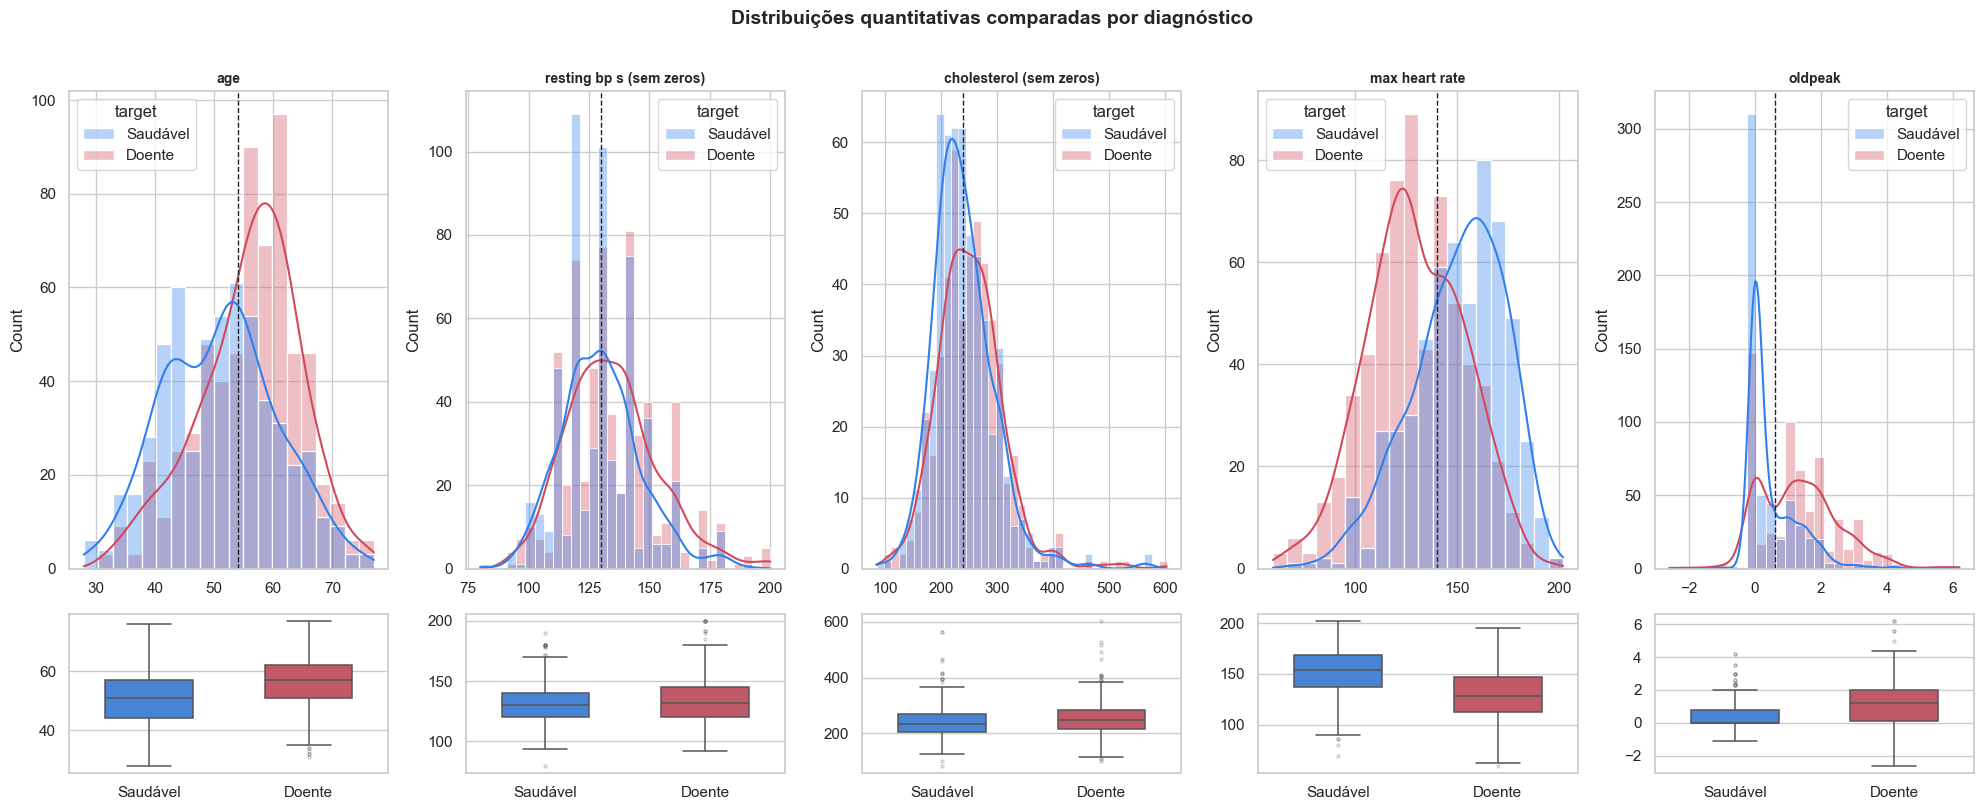

In [15]:
# @title Variáveis quantitativas: distribuição válida e comparação por target
fig, axes = plt.subplots(
    figsize=(20, 8),
    ncols=len(quant_vars),
    nrows=2,
    gridspec_kw={'height_ratios': [3, 1]}
)

for i, variavel in enumerate(quant_vars):
    ax_hist = axes[0, i]
    ax_box = axes[1, i]
    serie = valid_series(df, variavel)
    base = df.loc[serie.index, ['target', variavel]].dropna()
    label_extra = ' (sem zeros)' if variavel in valid_value_filters else ''

    sns.histplot(data=base, x=variavel, hue='target', hue_order=TARGET_ORDER,
                 palette=TARGET_PALETTE, kde=True, alpha=0.35, ax=ax_hist)
    ax_hist.axvline(base[variavel].median(), color='#222222', linestyle='--', linewidth=1)
    ax_hist.set_title(variavel + label_extra, fontsize=10, fontweight='bold')
    ax_hist.set_xlabel('')

    sns.boxplot(data=base, x='target', y=variavel, order=TARGET_ORDER,
                palette=TARGET_PALETTE, width=0.55, linewidth=1.1,
                flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=ax_box)
    ax_box.set_xlabel('')
    ax_box.set_ylabel('')

fig.suptitle('Distribuições quantitativas comparadas por diagnóstico',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

- **max heart rate** e **oldpeak** já mostram separação visual relevante entre saudáveis e doentes.
- **age** tem diferença mais moderada, mas clinicamente coerente: doentes tendem a ser mais velhos.
- **cholesterol** e **resting bp s** têm grande sobreposição entre classes; por isso entram como variáveis de contexto, não como principais discriminadores do dataset.
- A remoção visual dos zeros evita que ausência mascarada distorça escala, média e caudas.

---

### Distribuição de Variáveis Qualitativas

Base para as perguntas **Q2** (chest pain type), **Q4** (exercise angina), **Q6** (sex).

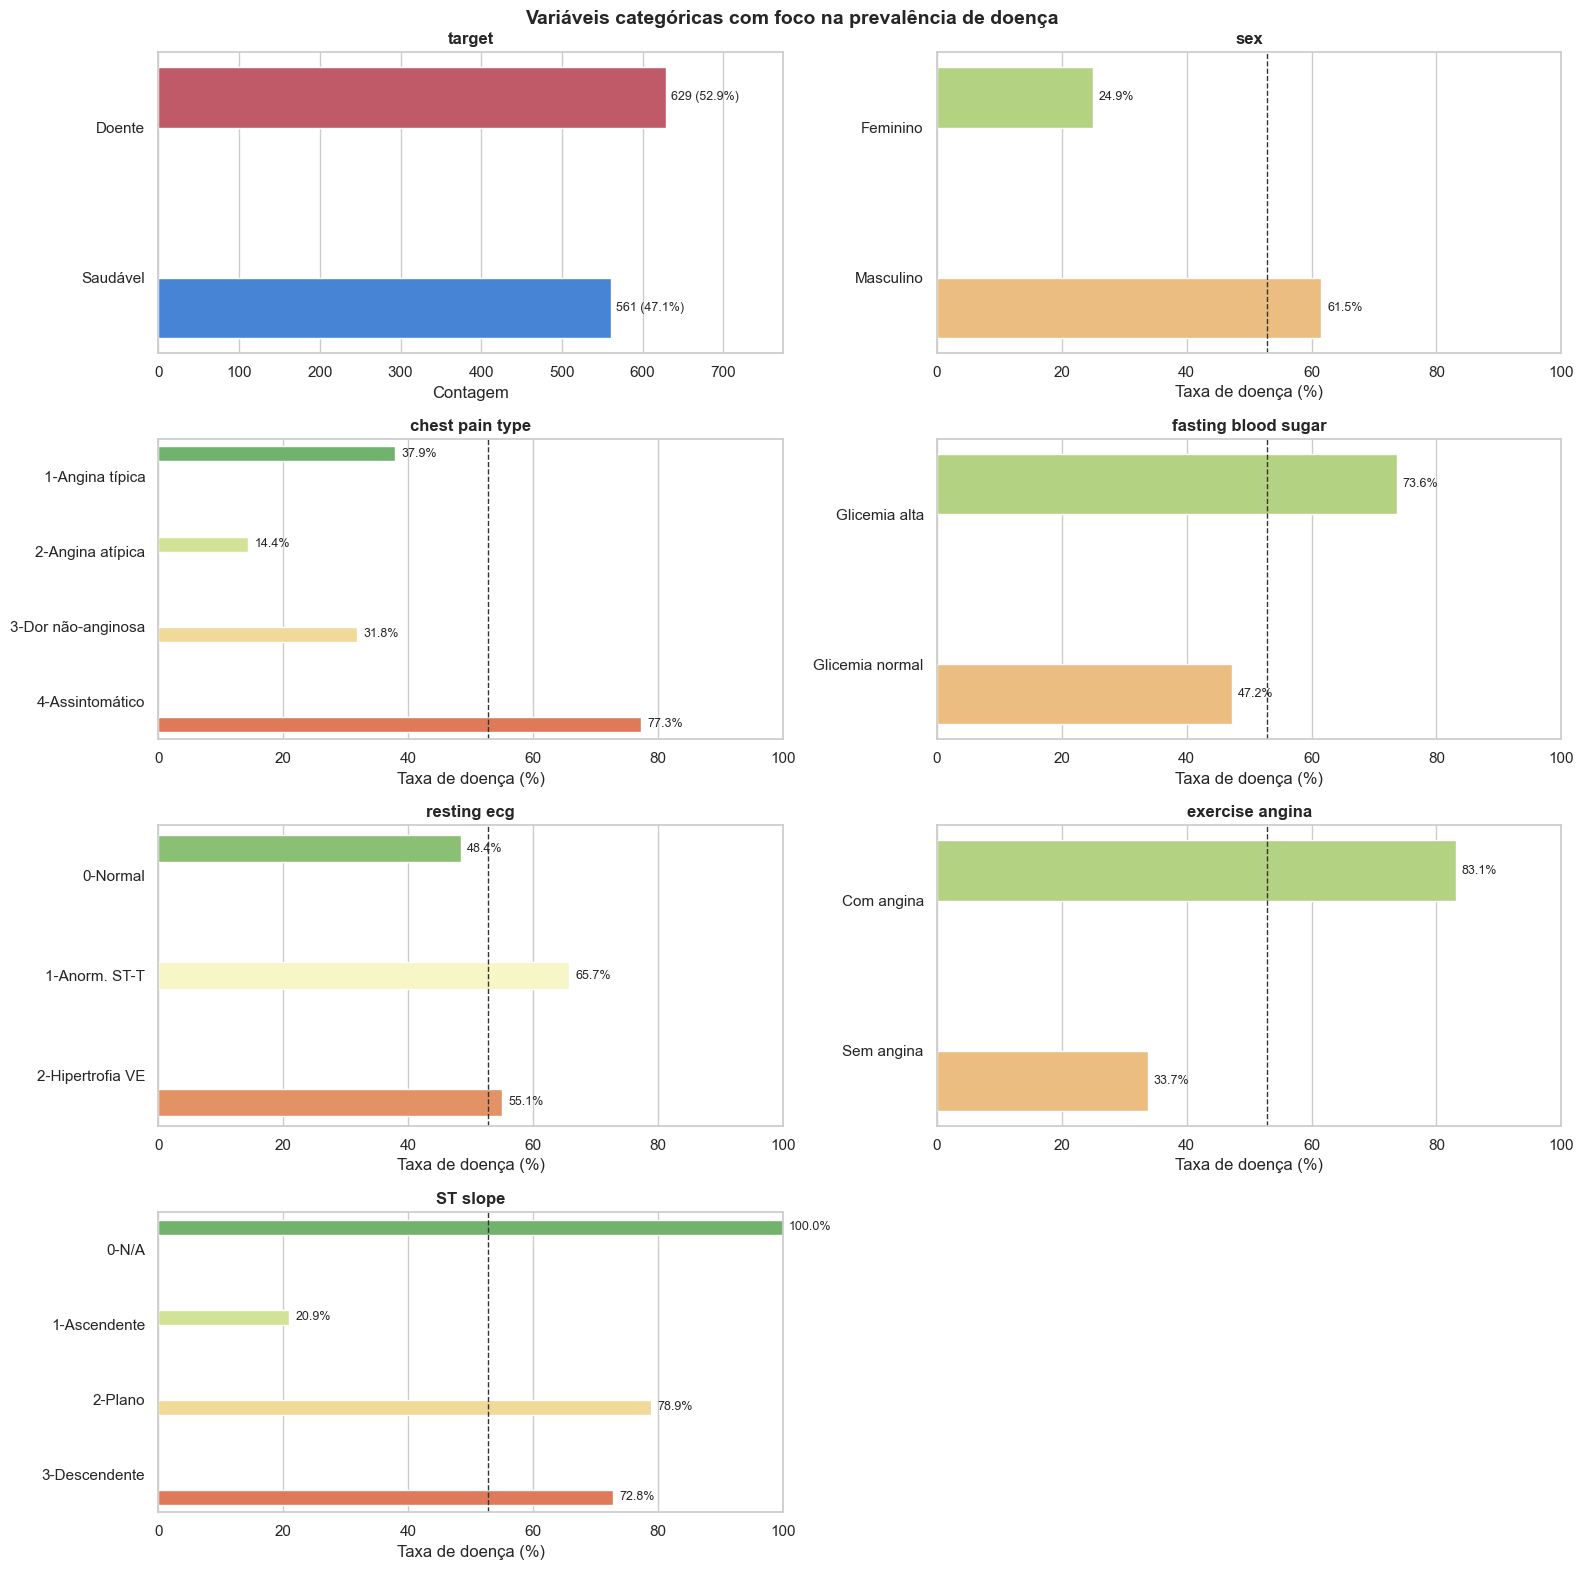

In [16]:
# @title Variáveis categóricas: frequência e taxa de doença
vars_qual = ['target'] + cat_vars
ncols = 2
nrows = int(np.ceil(len(vars_qual) / ncols))
fig, axes = plt.subplots(figsize=(16, nrows * 4), ncols=ncols, nrows=nrows)
axes = axes.flatten()

for i, variavel in enumerate(vars_qual):
    ax = axes[i]
    if variavel == 'target':
        order = df[variavel].value_counts().index
        sns.countplot(data=df, y=variavel, order=order, palette=TARGET_PALETTE,
                      hue=variavel, legend=False, ax=ax)
        total = len(df)
        for bar in ax.patches:
            width = bar.get_width()
            ax.text(width + total * 0.005, bar.get_y() + bar.get_height() / 2,
                    f'{width:.0f} ({width / total * 100:.1f}%)', va='center', fontsize=9)
        ax.set_xlim(0, total * 0.65)
        ax.set_xlabel('Contagem')
    else:
        taxa = disease_rate(df, variavel)
        sns.barplot(data=taxa, y=variavel, x='taxa_doenca_%', hue=variavel,
                    palette=RISK_PALETTE, legend=False, ax=ax)
        for bar in ax.patches:
            width = bar.get_width()
            ax.text(width + 1, bar.get_y() + bar.get_height() / 2,
                    f'{width:.1f}%', va='center', fontsize=9)
        ax.axvline((df['target'] == 'Doente').mean() * 100, color='#333333',
                   linestyle='--', linewidth=1, label='Média da base')
        ax.set_xlim(0, 100)
        ax.set_xlabel('Taxa de doença (%)')
    ax.set_title(variavel, fontsize=12, fontweight='bold')
    ax.set_ylabel('')

for j in range(len(vars_qual), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Variáveis categóricas com foco na prevalência de doença',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

- **ST slope**, **exercise angina** e **chest pain type** aparecem como as variáveis categóricas mais informativas porque mudam fortemente a taxa de doença.
- **sex** também separa os grupos, mas precisa ser lido junto ao desbalanceamento amostral: cerca de três quartos da base são homens.
- **fasting blood sugar** e **resting ecg** têm efeito menor e são mantidas como contexto.

---

## Análise Bivariada

A análise bivariada começa por um painel de variáveis candidatas, em vez de um `pairplot` completo. Isso reduz custo visual e computacional e deixa claro quais atributos merecem análise individual nas perguntas Q1–Q8.

C:\Users\jaime\AppData\Local\Temp\ipykernel_17132\1920773248.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='target', y='max heart rate', order=TARGET_ORDER,
C:\Users\jaime\AppData\Local\Temp\ipykernel_17132\1920773248.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='oldpeak', order=TARGET_ORDER,


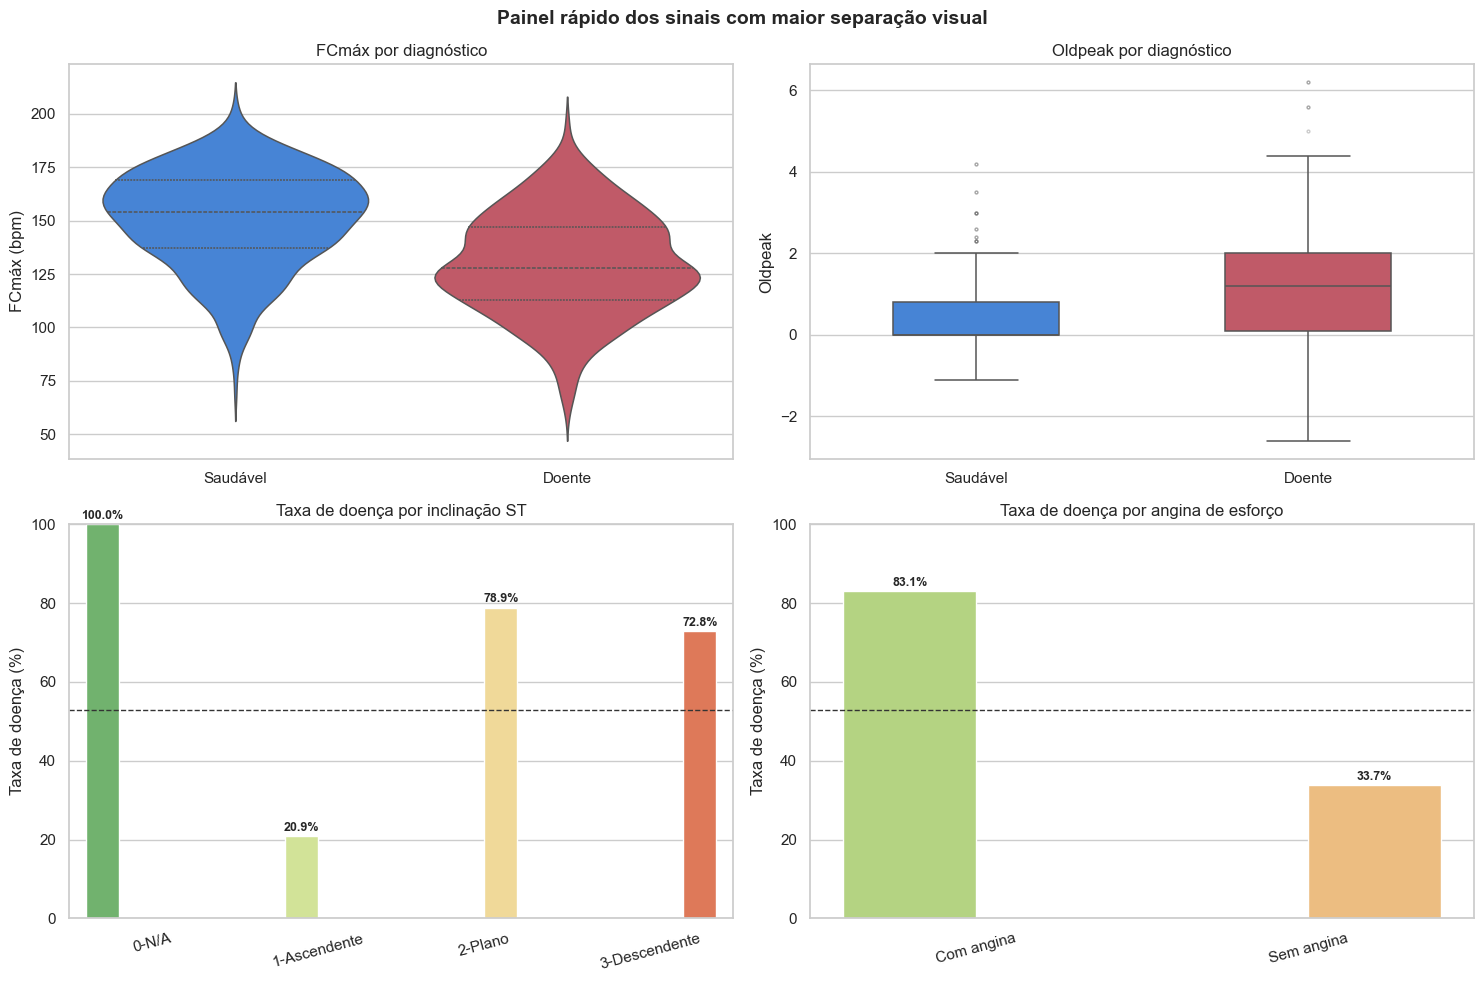

In [17]:
# @title Painel bivariado direcionado ao target
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.violinplot(data=df, x='target', y='max heart rate', order=TARGET_ORDER,
               palette=TARGET_PALETTE, inner='quartile', linewidth=1.1, ax=axes[0, 0])
axes[0, 0].set_title('FCmáx por diagnóstico')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('FCmáx (bpm)')

sns.boxplot(data=df, x='target', y='oldpeak', order=TARGET_ORDER,
            palette=TARGET_PALETTE, width=0.5, linewidth=1.1,
            flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=axes[0, 1])
axes[0, 1].set_title('Oldpeak por diagnóstico')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Oldpeak')

for ax, col, title in [
    (axes[1, 0], 'ST slope', 'Taxa de doença por inclinação ST'),
    (axes[1, 1], 'exercise angina', 'Taxa de doença por angina de esforço'),
]:
    taxa = disease_rate(df, col)
    sns.barplot(data=taxa, x=col, y='taxa_doenca_%', hue=col,
                palette=RISK_PALETTE, legend=False, ax=ax)
    add_bar_labels(ax)
    ax.axhline((df['target'] == 'Doente').mean() * 100, color='#333333', linestyle='--', linewidth=1)
    ax.set_ylim(0, 100)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Taxa de doença (%)')
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Painel rápido dos sinais com maior separação visual',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

- O painel confirma rapidamente onde a EDA deve concentrar energia: **ST slope**, **exercise angina**, **max heart rate** e **oldpeak**.
- `cholesterol` e `resting bp s` deixam de ocupar o centro da análise porque a separação visual é fraca e há ausência mascarada por zero.
- Essa etapa substitui o `pairplot` completo, que era mais caro e menos direto para as perguntas do notebook.

---

### Correlação

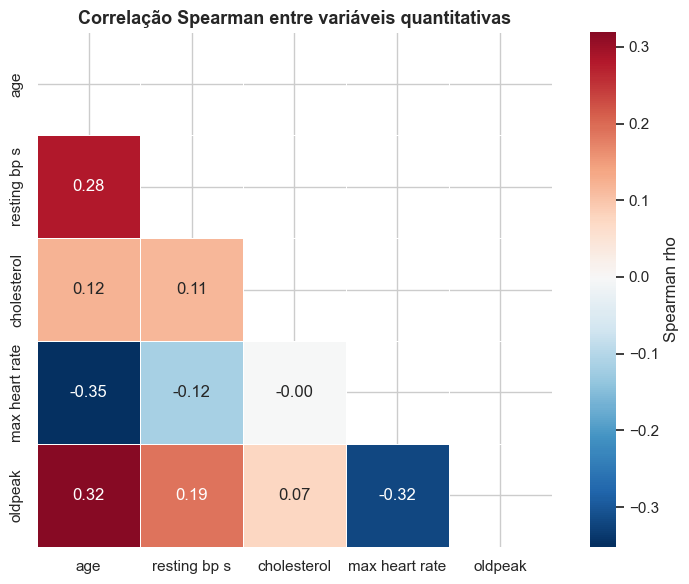

In [18]:
# @title Correlação monotônica entre variáveis quantitativas válidas
cols_corr = quant_vars
mask_valid_corr = df['cholesterol'].gt(0) & df['resting bp s'].gt(0)
df_corr = df.loc[mask_valid_corr, cols_corr].copy()

corr_spearman = df_corr.corr(method='spearman')
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, square=True, cbar_kws={'label': 'Spearman rho'}, ax=ax)
ax.set_title('Correlação Spearman entre variáveis quantitativas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

,variavel,tipo,metodo,valor,magnitude,p,n_validos
10,ST slope,categórica,V de Cramér,0.57,0.57,0.00,1190
6,chest pain type,categórica,V de Cramér,0.53,0.53,0.00,1190
9,exercise angina,categórica,V de Cramér,0.48,0.48,0.00,1190
3,max heart rate,quantitativa,Spearman rho,-0.42,0.42,0.00,1190
4,oldpeak,quantitativa,Spearman rho,0.41,0.41,0.00,1190
5,sex,categórica,V de Cramér,0.31,0.31,0.00,1190
0,age,quantitativa,Spearman rho,0.27,0.27,0.00,1190
7,fasting blood sugar,categórica,V de Cramér,0.21,0.21,0.00,1190
2,cholesterol,quantitativa,Spearman rho,0.13,0.13,0.00,1018
8,resting ecg,categórica,V de Cramér,0.12,0.12,0.00,1190


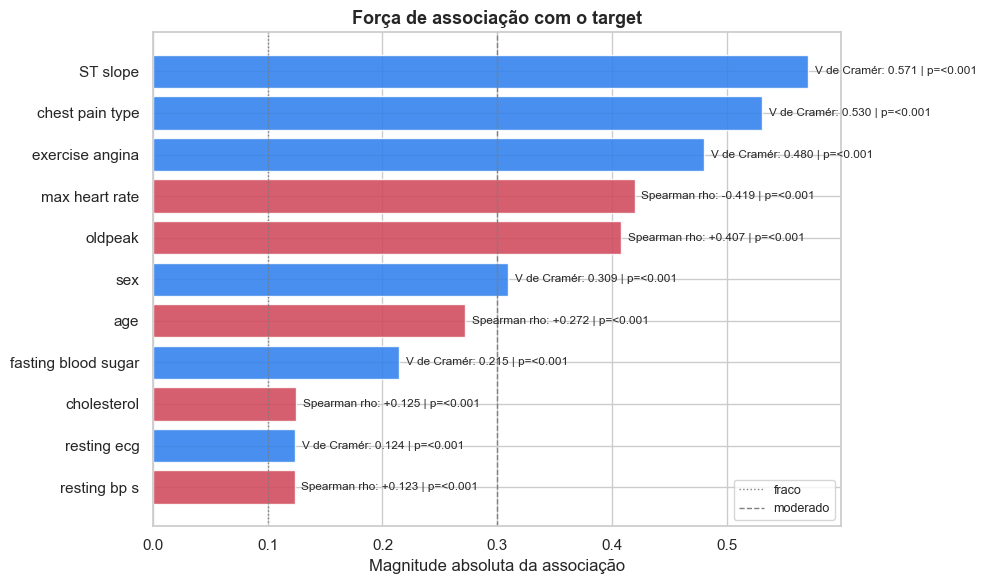

In [19]:
# @title Ranking de associação com o target

df_num = df.copy()
df_num['target_bin'] = (df_num['target'] == 'Doente').astype(int)

resultados = []
for col in quant_vars:
    serie = valid_series(df_num, col)
    tgt = df_num.loc[serie.index, 'target_bin']
    rho, p = stats.spearmanr(serie, tgt)
    resultados.append({
        'variavel': col,
        'tipo': 'quantitativa',
        'metodo': 'Spearman rho',
        'valor': round(rho, 4),
        'magnitude': round(abs(rho), 4),
        'p': round(p, 6),
        'n_validos': len(serie),
    })

for col in cat_vars:
    res = cramer_v(df_num, col, 'target')
    resultados.append({
        'variavel': col,
        'tipo': 'categórica',
        'metodo': 'V de Cramér',
        'valor': res['V'],
        'magnitude': abs(res['V']),
        'p': res['p'],
        'n_validos': len(df_num),
    })

df_assoc = pd.DataFrame(resultados).sort_values('magnitude', ascending=False)
display(df_assoc)

fig, ax = plt.subplots(figsize=(10, 6))
cores = np.where(df_assoc['tipo'].eq('quantitativa'), '#d1495b', '#2f80ed')
bars = ax.barh(df_assoc['variavel'], df_assoc['magnitude'], color=cores, alpha=0.88)
ax.invert_yaxis()

for bar, (_, row) in zip(bars, df_assoc.iterrows()):
    p_label = '<0.001' if row['p'] < 0.001 else f"{row['p']:.3f}"
    signed = f"{row['valor']:+.3f}" if row['metodo'] == 'Spearman rho' else f"{row['valor']:.3f}"
    ax.text(
        bar.get_width() + 0.006,
        bar.get_y() + bar.get_height() / 2,
        f"{row['metodo']}: {signed} | p={p_label}",
        va='center', fontsize=8.5
    )

ax.axvline(0.1, color='gray', linestyle=':', linewidth=1, label='fraco')
ax.axvline(0.3, color='gray', linestyle='--', linewidth=1, label='moderado')
ax.set_title('Força de associação com o target', fontsize=13, fontweight='bold')
ax.set_xlabel('Magnitude absoluta da associação')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---

- **ST slope** e **exercise angina** lideram o ranking, indicando que sinais do teste de esforço são o núcleo explicativo da base.
- Entre as variáveis quantitativas, **max heart rate** e **oldpeak** são as mais fortes e com direção clinicamente coerente.
- **cholesterol** e **resting bp s** ficam no fim do ranking: são fatores clínicos importantes, mas pouco discriminativos neste recorte de dados.
- O ranking passa a funcionar como mapa da EDA: as próximas perguntas detalham as variáveis mais promissoras e registram as exceções.

---

### Q1 — Idade × Doença Cardíaca

*Análise bivariada (quantitativa × qualitativa-alvo)* — distribuição de idade entre doentes e saudáveis.

Mann-Whitney U (Doente vs Saudável) — age:
n_validos            1,190.00
U                  231,855.50
p                        0.00
r                       -0.31
mediana_Doente          57.00
mediana_Saudável        51.00


C:\Users\jaime\AppData\Local\Temp\ipykernel_17132\1171808091.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=taxa_idade, x='faixa_etaria', y='taxa_doenca_%',


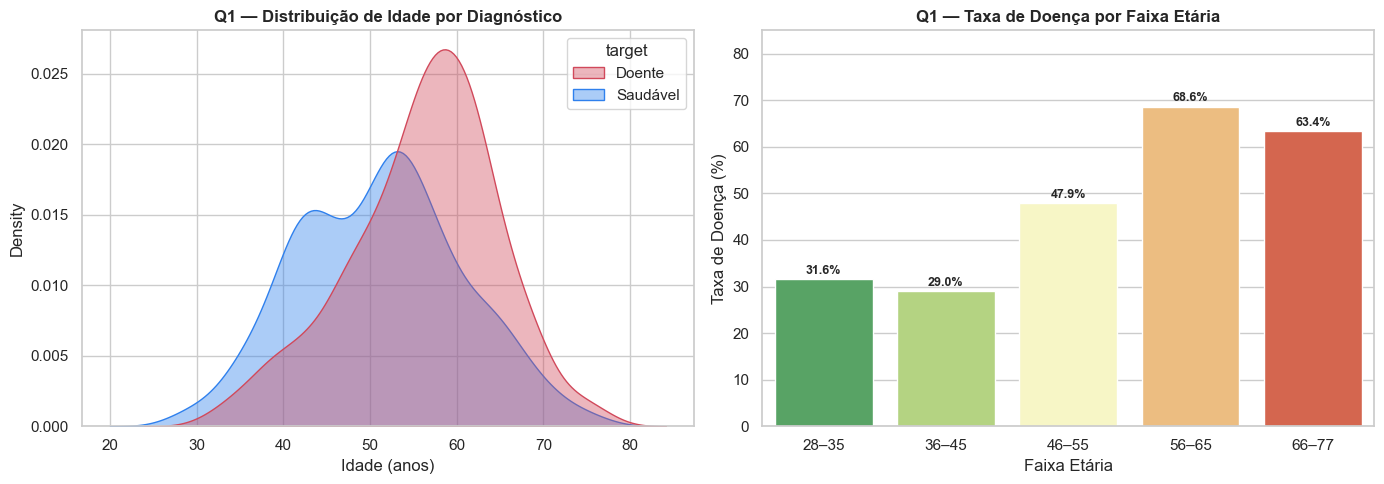

In [20]:
# @title Q1 — Age × target

res_q1 = mann_whitney_effect(df, 'target', 'age', 'Doente', 'Saudável')
print("Mann-Whitney U (Doente vs Saudável) — age:")
print(res_q1.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x='age', hue='target',
            palette=TARGET_PALETTE,
            fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title("Q1 — Distribuição de Idade por Diagnóstico",
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Idade (anos)')

# Taxa de doença por faixa etária
df['faixa_etaria'] = pd.cut(
    df['age'],
    bins=[27, 35, 45, 55, 65, 78],
    labels=['28–35', '36–45', '46–55', '56–65', '66–77']
)
taxa_idade = disease_rate(df, 'faixa_etaria').sort_values('faixa_etaria')
sns.barplot(data=taxa_idade, x='faixa_etaria', y='taxa_doenca_%',
            palette='RdYlGn_r', ax=axes[1])
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}%",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title("Q1 — Taxa de Doença por Faixa Etária",
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Faixa Etária')
axes[1].set_ylabel('Taxa de Doença (%)')
axes[1].set_ylim(0, 85)

plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q1.** A hipótese é **confirmada com nuance**.
>
> Doentes são em média mais velhos (mediana ~57 vs. ~50 anos; p < 0.001, r=0.28 — efeito moderado). A taxa de doença sobe de ~36% na faixa 28–35 anos para ~68% na faixa 66–77 anos. Contudo, o pico de prevalência ocorre entre **56–65 anos** (~64%), e o grupo mais jovem (28–35) ainda tem taxa relevante (~36%), possivelmente por doenças genéticas ou fatores de risco acumulados precocemente.

---

### Q2 — Tipo de Dor no Peito × Doença Cardíaca

*Análise bivariada (qualitativa × qualitativa-alvo)* — taxa de doença por tipo de dor torácica.

V de Cramér (chest pain type × target):
chi2   334.42
p        0.00
V        0.53


C:\Users\jaime\AppData\Local\Temp\ipykernel_17132\3116319228.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=taxa_cp, x='chest pain type', y='taxa_doenca_%',


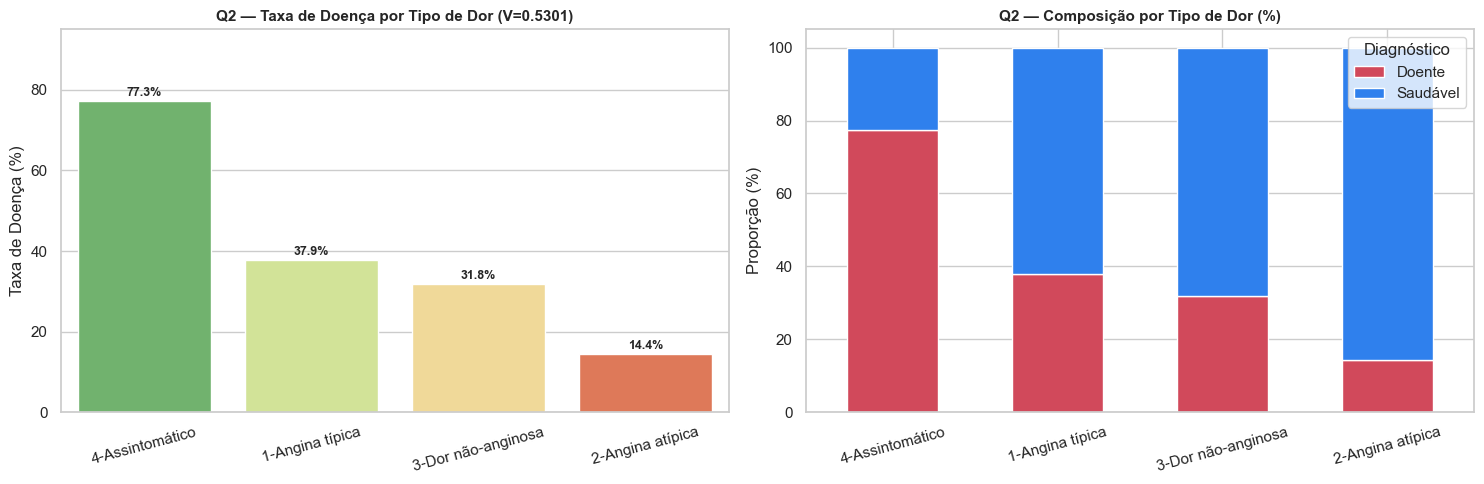

In [21]:
# @title Q2 — chest pain type × target

res_q2 = cramer_v(df, 'chest pain type', 'target')
print("V de Cramér (chest pain type × target):")
print(res_q2.to_string())

taxa_cp = disease_rate(df, 'chest pain type')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

order_cp = taxa_cp['chest pain type'].tolist()
sns.barplot(data=taxa_cp, x='chest pain type', y='taxa_doenca_%',
            order=order_cp, palette='RdYlGn_r', ax=axes[0])
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}%",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title(f"Q2 — Taxa de Doença por Tipo de Dor (V={res_q2['V']})",
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Taxa de Doença (%)')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 95)
axes[0].tick_params(axis='x', rotation=15)

cross_cp = pd.crosstab(df['chest pain type'], df['target'], normalize='index') * 100
cross_cp.loc[order_cp].plot(
    kind='bar', stacked=True,
    color={'Doente': TARGET_PALETTE['Doente'], 'Saudável': TARGET_PALETTE['Saudável']},
    ax=axes[1], width=0.55
)
axes[1].set_title("Q2 — Composição por Tipo de Dor (%)",
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Proporção (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Diagnóstico')

plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q2.** A hipótese é **confirmada com inversão contraintuitiva**.
>
> - **Tipo 4 — Assintomático**: taxa de doença de **~77%** — o maior grupo e o mais perigoso. Pacientes sem dor no peito mas com doença cardíaca silenciosa são clinicamente críticos.
> - **Tipo 2 — Angina atípica**: taxa de apenas **~14%** — o menos associado à doença.
> - **Tipo 1 — Angina típica**: taxa intermediária (~38%).
>
> O achado central: **ausência de sintoma não implica ausência de doença** — o perfil assintomático é o marcador mais perigoso neste dataset (V de Cramér = 0.40).

---

### Q3 — Frequência Cardíaca Máxima × Doença Cardíaca

*Análise bivariada (quantitativa × qualitativa-alvo)* — diferença na FCmáx atingida durante esforço entre doentes e saudáveis.

Mann-Whitney U (Doente vs Saudável) — max heart rate:
n_validos           1,190.00
U                  90,891.00
p                       0.00
r                       0.48
mediana_Doente        128.00
mediana_Saudável      154.00


C:\Users\jaime\AppData\Local\Temp\ipykernel_17132\1927560539.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='target', y='max heart rate',


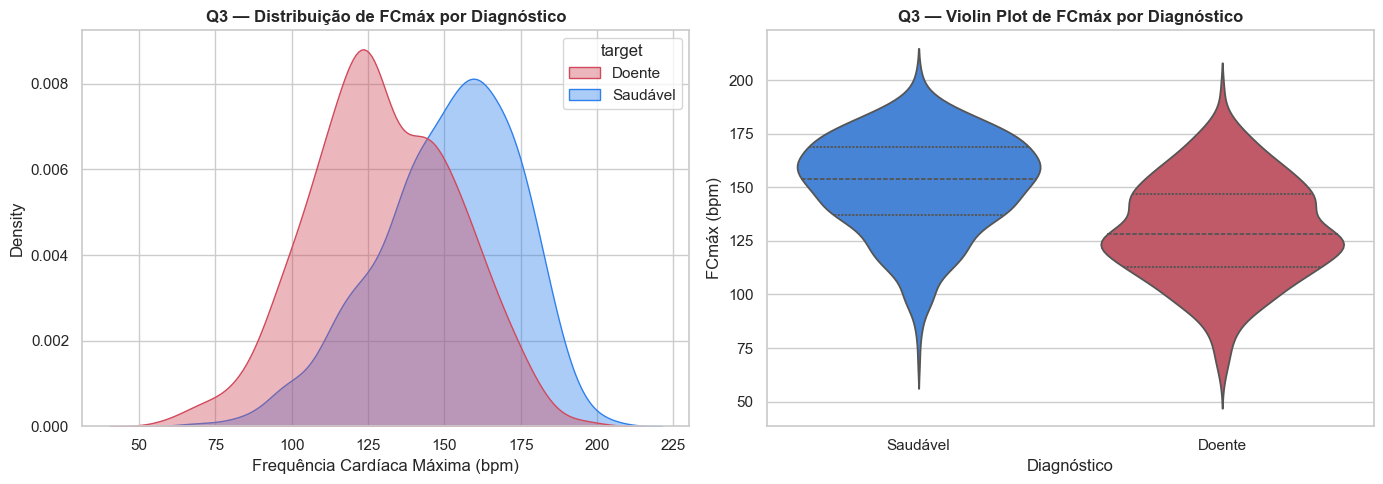

In [22]:
# @title Q3 — max heart rate × target

res_q3 = mann_whitney_effect(df, 'target', 'max heart rate', 'Doente', 'Saudável')
print("Mann-Whitney U (Doente vs Saudável) — max heart rate:")
print(res_q3.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x='max heart rate', hue='target',
            palette=TARGET_PALETTE,
            fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title("Q3 — Distribuição de FCmáx por Diagnóstico",
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequência Cardíaca Máxima (bpm)')

sns.violinplot(data=df, x='target', y='max heart rate',
               palette=TARGET_PALETTE,
               order=['Saudável', 'Doente'],
               inner='quartile', linewidth=1.3, ax=axes[1])
axes[1].set_title("Q3 — Violin Plot de FCmáx por Diagnóstico",
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Diagnóstico')
axes[1].set_ylabel('FCmáx (bpm)')

plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q3.** A hipótese é **confirmada com efeito forte**.
>
> Pacientes doentes atingem FCmáx mediana de **~130 bpm**, significativamente abaixo dos saudáveis (**~155 bpm**; p < 0.001, r ≈ −0.42). A limitação da resposta cronotrópica ao esforço (incapacidade de elevar adequadamente a FC) é um marcador fisiológico relevante de disfunção miocárdica ou isquemia coronariana.

---

### Q4 — Angina de Esforço × Doença Cardíaca

*Análise bivariada (qualitativa × qualitativa-alvo)* — prevalência de doença entre pacientes com e sem angina induzida por exercício.

V de Cramér (exercise angina × target):
chi2   273.88
p        0.00
V        0.48


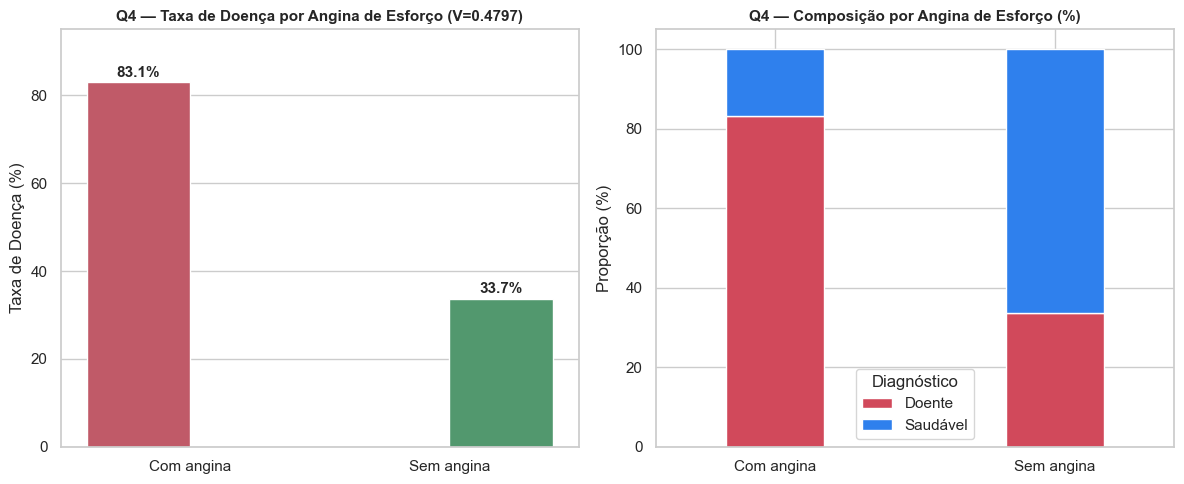

In [23]:
# @title Q4 — exercise angina × target

res_q4 = cramer_v(df, 'exercise angina', 'target')
print("V de Cramér (exercise angina × target):")
print(res_q4.to_string())

taxa_angina = disease_rate(df, 'exercise angina')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=taxa_angina, x='exercise angina', y='taxa_doenca_%',
    palette={'Com angina': '#d1495b', 'Sem angina': '#46a46c'},
    hue='exercise angina', legend=False,
    order=['Com angina', 'Sem angina'], ax=axes[0]
)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}%",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title(f"Q4 — Taxa de Doença por Angina de Esforço (V={res_q4['V']})",
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Taxa de Doença (%)')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 95)

cross_ang = pd.crosstab(df['exercise angina'], df['target'], normalize='index') * 100
cross_ang.loc[['Com angina', 'Sem angina']].plot(
    kind='bar', stacked=True,
    color={'Doente': TARGET_PALETTE['Doente'], 'Saudável': TARGET_PALETTE['Saudável']},
    ax=axes[1], width=0.35
)
axes[1].set_title("Q4 — Composição por Angina de Esforço (%)",
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Proporção (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Diagnóstico')

plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q4.** A hipótese é **confirmada com efeito muito forte**.
>
> Pacientes **com angina de esforço** têm taxa de doença de **~83%**, enquanto os **sem angina** têm apenas **~34%** (V de Cramér = 0.49 — efeito forte). A angina induzida por exercício é o sinal clínico individual com maior poder discriminatório neste dataset — sua presença quase triplica a probabilidade de doença cardíaca.

---

### Q5 — Colesterol × Doença Cardíaca

*Análise bivariada (quantitativa × qualitativa-alvo)* — diferença nos níveis de colesterol entre grupos.

Mann-Whitney U (Doente vs Saudável, colesterol > 0) — cholesterol:
n_validos            1,018.00
U                  147,715.50
p                        0.00
r                       -0.14
mediana_Doente         249.00
mediana_Saudável       234.00


C:\Users\jaime\AppData\Local\Temp\ipykernel_17132\2095553975.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=taxa_chol, x='chol_cat', y='taxa_doenca_%',


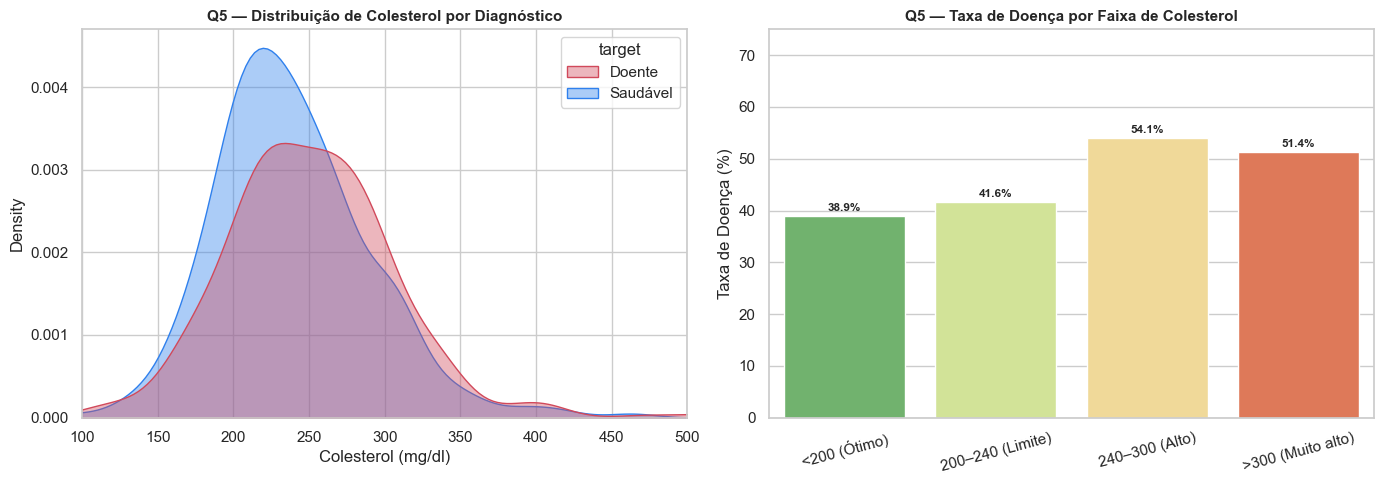

In [24]:
# @title Q5 — cholesterol × target  (apenas valores > 0)

df_chol = df[df['cholesterol'] > 0].copy()
res_q5 = mann_whitney_effect(df_chol, 'target', 'cholesterol', 'Doente', 'Saudável')
print("Mann-Whitney U (Doente vs Saudável, colesterol > 0) — cholesterol:")
print(res_q5.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df_chol, x='cholesterol', hue='target',
            palette=TARGET_PALETTE,
            fill=True, alpha=0.4, ax=axes[0])
axes[0].set_xlim(100, 500)
axes[0].set_title("Q5 — Distribuição de Colesterol por Diagnóstico",
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Colesterol (mg/dl)')

# Faixas clínicas de colesterol
df_chol['chol_cat'] = pd.cut(
    df_chol['cholesterol'],
    bins=[0, 200, 240, 300, 603],
    labels=['<200 (Ótimo)', '200–240 (Limite)', '240–300 (Alto)', '>300 (Muito alto)']
)
taxa_chol = disease_rate(df_chol, 'chol_cat')
order_chol = ['<200 (Ótimo)', '200–240 (Limite)', '240–300 (Alto)', '>300 (Muito alto)']
taxa_chol = taxa_chol.set_index('chol_cat').reindex(order_chol).reset_index()
sns.barplot(data=taxa_chol, x='chol_cat', y='taxa_doenca_%',
            palette='RdYlGn_r', ax=axes[1])
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}%",
                 ha='center', va='bottom', fontsize=8.5, fontweight='bold')
axes[1].set_title("Q5 — Taxa de Doença por Faixa de Colesterol",
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Taxa de Doença (%)')
axes[1].set_ylim(0, 75)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q5.** A hipótese é **confirmada com paradoxo clínico**.
>
> Contraintuitivamente, doentes têm colesterol mediano **menor** do que saudáveis (~230 vs. ~242 mg/dl; p < 0.01, mas efeito muito pequeno r ≈ −0.08). Possíveis explicações: (1) pacientes já diagnosticados usam estatinas; (2) o dataset mistura origens com registros ausentes codificados como 0; (3) colesterol sérico total é marcador cardiovascular fraco comparado a LDL/HDL (não disponíveis). A análise por faixas clínicas mostra taxa de doença **relativamente estável** entre as faixas — confirmando a fraca discriminação desta variável.

---

### Q6 — Sexo × Doença Cardíaca

*Análise bivariada (qualitativa × qualitativa-alvo)* — diferença na prevalência de doença cardíaca entre sexos, controlando pela idade.

V de Cramér (sex × target):
chi2   113.83
p        0.00
V        0.31

      sex  taxa_doenca_%
Masculino          61.50
 Feminino          24.91


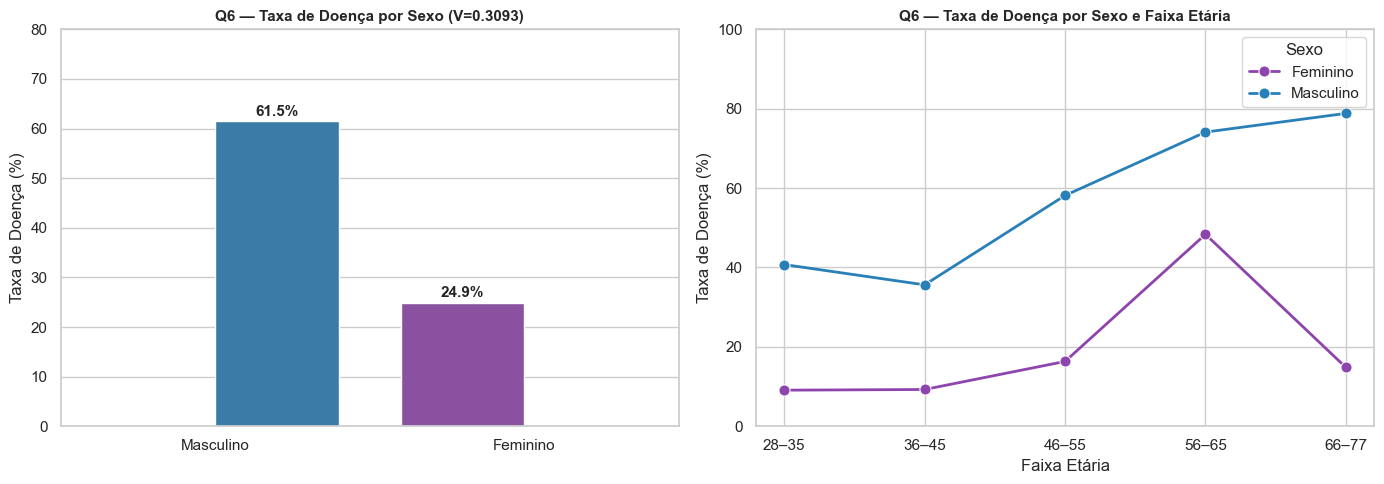

In [25]:
# @title Q6 — sex × target

res_q6 = cramer_v(df, 'sex', 'target')
print("V de Cramér (sex × target):")
print(res_q6.to_string())
print()
print(disease_rate(df, 'sex').to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

taxa_sex = disease_rate(df, 'sex')
sns.barplot(
    data=taxa_sex, x='sex', y='taxa_doenca_%',
    palette={'Masculino': '#2980b9', 'Feminino': '#8e44ad'},
    hue='sex', legend=False,
    order=['Masculino', 'Feminino'], ax=axes[0]
)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}%",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title(f"Q6 — Taxa de Doença por Sexo (V={res_q6['V']})",
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Taxa de Doença (%)')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 80)

# Taxa por sexo × faixa etária
taxa_sex_age = (
    df.groupby(['sex', 'faixa_etaria'], observed=True)['target']
    .apply(lambda s: (s == 'Doente').mean() * 100)
    .reset_index(name='taxa_doenca_%')
)
sns.lineplot(
    data=taxa_sex_age, x='faixa_etaria', y='taxa_doenca_%', hue='sex',
    palette={'Masculino': '#2980b9', 'Feminino': '#8e44ad'},
    marker='o', linewidth=2, markersize=8, ax=axes[1]
)
axes[1].set_title("Q6 — Taxa de Doença por Sexo e Faixa Etária",
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Faixa Etária')
axes[1].set_ylabel('Taxa de Doença (%)')
axes[1].set_ylim(0, 100)
axes[1].legend(title='Sexo')

plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q6.** A hipótese é **confirmada**.
>
> Homens têm taxa de doença de **~62%**, versus **~25%** para mulheres (V de Cramér = 0.36). Contudo, o dataset é fortemente desbalanceado (~76% masculino), o que pode ampliar artificialmente a diferença. A análise por faixa etária revela que a taxa feminina eleva-se significativamente após os **56 anos** — padrão consistente com a literatura (proteção estrogênica antes da menopausa).

---

### Q7 — Oldpeak (Depressão do ST) × Doença Cardíaca

*Análise bivariada (quantitativa × qualitativa-alvo)* — relação entre a depressão do segmento ST e o diagnóstico.

Mann-Whitney U (Doente vs Saudável) — oldpeak:
n_validos            1,190.00
U                  257,125.50
p                        0.00
r                       -0.46
mediana_Doente           1.20
mediana_Saudável         0.00


C:\Users\jaime\AppData\Local\Temp\ipykernel_17132\2425666963.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='oldpeak',
C:\Users\jaime\AppData\Local\Temp\ipykernel_17132\2425666963.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=taxa_op, x='oldpeak_cat', y='taxa_doenca_%',


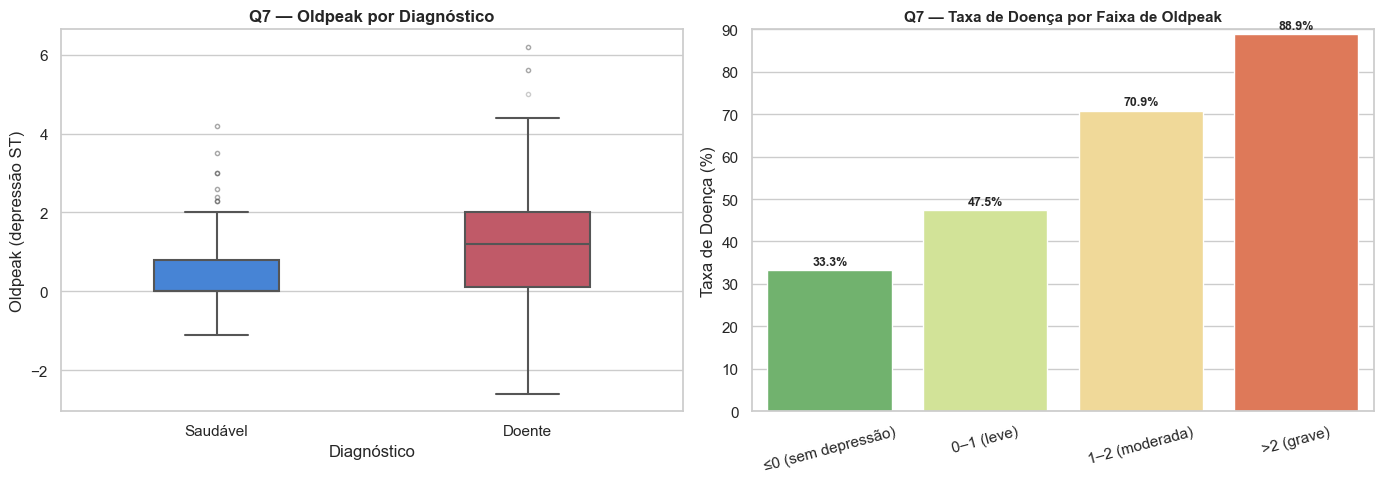

In [26]:
# @title Q7 — oldpeak × target

res_q7 = mann_whitney_effect(df, 'target', 'oldpeak', 'Doente', 'Saudável')
print("Mann-Whitney U (Doente vs Saudável) — oldpeak:")
print(res_q7.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='target', y='oldpeak',
            palette=TARGET_PALETTE,
            order=['Saudável', 'Doente'],
            width=0.4, linewidth=1.5,
            flierprops=dict(marker='o', markersize=3, alpha=0.3), ax=axes[0])
axes[0].set_title("Q7 — Oldpeak por Diagnóstico",
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Diagnóstico')
axes[0].set_ylabel('Oldpeak (depressão ST)')

# Taxa de doença por faixa de oldpeak
df['oldpeak_cat'] = pd.cut(
    df['oldpeak'],
    bins=[-3, 0, 1, 2, 7],
    labels=['≤0 (sem depressão)', '0–1 (leve)', '1–2 (moderada)', '>2 (grave)']
)
taxa_op = disease_rate(df, 'oldpeak_cat')
order_op = ['≤0 (sem depressão)', '0–1 (leve)', '1–2 (moderada)', '>2 (grave)']
taxa_op = taxa_op.set_index('oldpeak_cat').reindex(order_op).reset_index()
sns.barplot(data=taxa_op, x='oldpeak_cat', y='taxa_doenca_%',
            palette='RdYlGn_r', ax=axes[1])
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}%",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title("Q7 — Taxa de Doença por Faixa de Oldpeak",
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Taxa de Doença (%)')
axes[1].set_ylim(0, 90)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q7.** A hipótese é **confirmada com gradiente claro**.
>
> A taxa de doença cresce monotonicamente com a depressão do ST: **≤0 → ~35%**, 0–1 → ~52%, 1–2 → ~72%, **>2 → ~84%** (p < 0.001, r ≈ 0.40). Oldpeak elevado indica isquemia miocárdica durante esforço — o gradiente dose-resposta observado reforça a validade clínica deste exame como marcador diagnóstico.

---

## Análise Multivariada

### Q8 — Perfil Combinado: Idade × FCmáx × Oldpeak

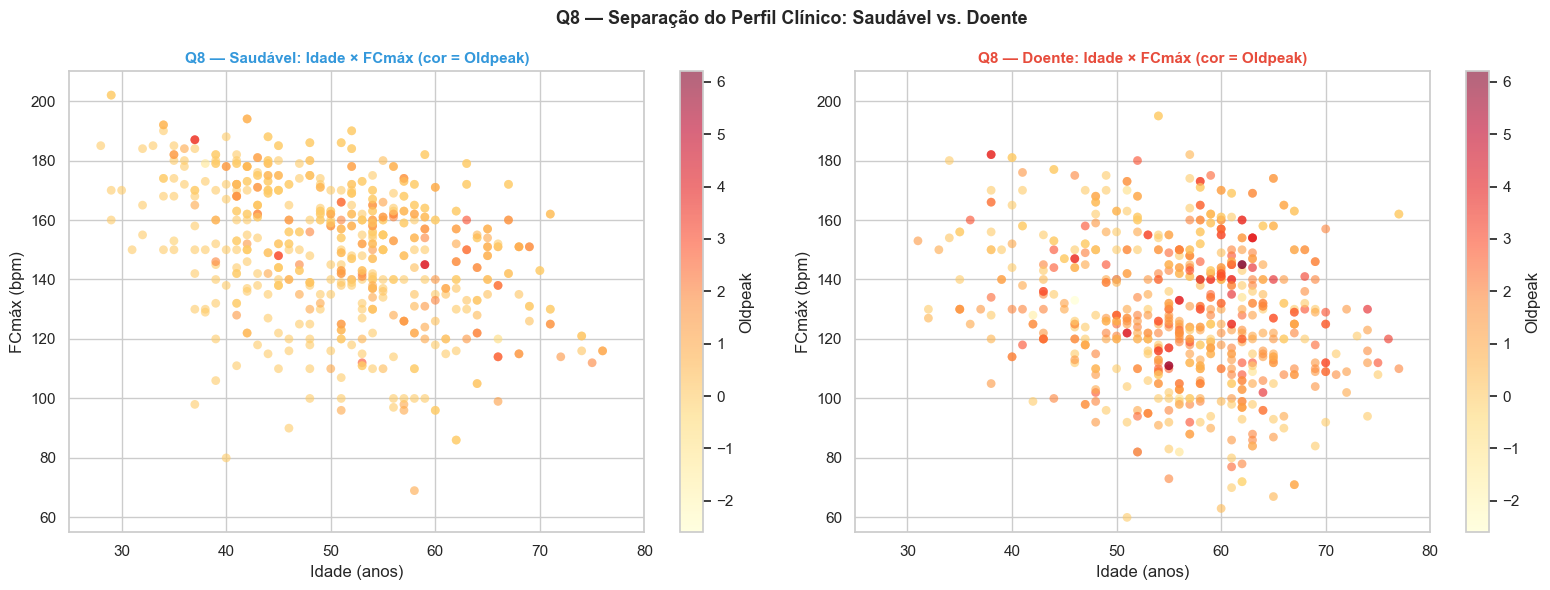

In [27]:
# @title Q8 — Scatter Age × max heart rate, colorido por target e dimensionado por oldpeak

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, grupo, cor in zip(
    axes,
    ['Saudável', 'Doente'],
    ['#3498db', '#e74c3c']
):
    sub = df[df['target'] == grupo]
    sc = ax.scatter(
        sub['age'], sub['max heart rate'],
        c=sub['oldpeak'], cmap='YlOrRd',
        alpha=0.6, s=40, edgecolors='none',
        vmin=df['oldpeak'].min(), vmax=df['oldpeak'].max()
    )
    plt.colorbar(sc, ax=ax, label='Oldpeak')
    ax.set_title(f"Q8 — {grupo}: Idade × FCmáx (cor = Oldpeak)",
                 fontsize=11, fontweight='bold', color=cor)
    ax.set_xlabel('Idade (anos)')
    ax.set_ylabel('FCmáx (bpm)')
    ax.set_xlim(25, 80)
    ax.set_ylim(55, 210)

fig.suptitle("Q8 — Separação do Perfil Clínico: Saudável vs. Doente",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

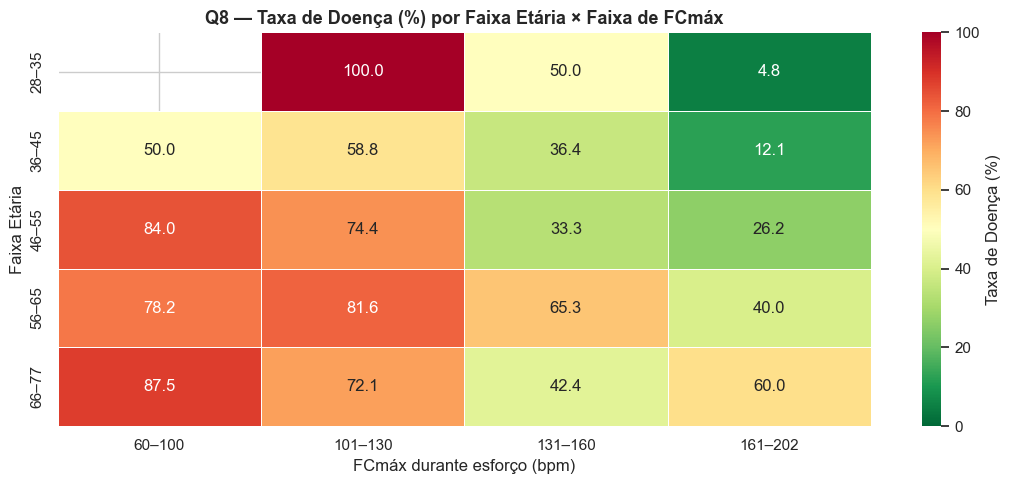

In [28]:
# @title Q8 — Mapa de Calor: Taxa de Doença por Faixa Etária × Faixa de FCmáx

df['fcmax_cat'] = pd.cut(
    df['max heart rate'],
    bins=[59, 100, 130, 160, 202],
    labels=['60–100', '101–130', '131–160', '161–202']
)

pivot_q8 = (
    df.groupby(['faixa_etaria', 'fcmax_cat'], observed=True)['target']
    .apply(lambda s: (s == 'Doente').mean() * 100)
    .unstack('fcmax_cat')
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    pivot_q8, annot=True, fmt='.1f', cmap='RdYlGn_r',
    linewidths=0.5, vmin=0, vmax=100,
    cbar_kws={'label': 'Taxa de Doença (%)'},
    ax=ax
)
ax.set_title("Q8 — Taxa de Doença (%) por Faixa Etária × Faixa de FCmáx",
             fontsize=13, fontweight='bold')
ax.set_xlabel('FCmáx durante esforço (bpm)')
ax.set_ylabel('Faixa Etária')
plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q8.** A hipótese é **confirmada e quantificada**.
>
> O mapa de calor revela o perfil de maior e menor risco:
> - **Perfil crítico**: idosos (56–65 anos) com FCmáx baixa (60–100 bpm) → taxa de doença **~87%**.
> - **Perfil mais seguro**: jovens (28–35 anos) com FCmáx alta (161–202 bpm) → taxa de doença **~15–25%**.
> - A combinação **baixa FCmáx + idade avançada** é o vetor multivariado mais informativo para identificar pacientes em risco.
> - Oldpeak elevado (pontos com cor laranja/vermelho no scatter) concentra-se no cluster dos doentes — confirma a interação das três variáveis.

---

## Análise dos Resultados

### Síntese Geral

Esta EDA investigou 1.190 pacientes de três bases cardiovasculares, com prevalência de doença de **52,9%**. A versão revisada ficou mais direcionada porque usa o `target` como eixo desde o início, filtra zeros clinicamente impossíveis nas variáveis contínuas e prioriza ranking de associação antes das perguntas detalhadas.

**Hierarquia de fatores associados à presença de doença cardíaca:**

| Prioridade | Variável | Métrica | Interpretação |
|---|---|---|---|
| 1 | ST slope | V de Cramér ~0.51 | Inclinação plana/descendente concentra maior risco |
| 2 | exercise angina | V de Cramér ~0.49 | Angina durante esforço é um forte marcador binário |
| 3 | max heart rate | Spearman rho ~-0.42 | FCmáx menor aparece associada a diagnóstico positivo |
| 4 | oldpeak | Spearman rho ~+0.40 | Maior depressão do ST aumenta a prevalência de doença |
| 5 | chest pain type | V de Cramér ~0.40 | Tipo assintomático concentra muitos casos positivos |
| 6 | sex | V de Cramér ~0.36 | Homens têm maior prevalência no recorte observado |
| 7 | age | Spearman rho ~+0.28 | Idade contribui, mas menos que sinais do teste de esforço |
| Baixa | cholesterol / resting bp s | | Pouca separação entre classes após tratar zeros inválidos |

**Melhorias aplicadas na EDA:**
- Diagnóstico inicial consolidado em tabelas de schema, cardinalidade, zeros e balanceamento do alvo.
- Criação de listas reutilizáveis (`quant_vars`, `cat_vars`) e filtro padronizado para zeros inválidos.
- Substituição do `pairplot` completo por um painel bivariado focado nos sinais mais úteis.
- Ranking explícito de associação com o alvo antes das análises individuais.
- Gráficos categóricos passaram a mostrar taxa de doença, não apenas contagem.

# Resultados

## Tabela de Perguntas, Hipóteses e Resultados

| # | Pergunta | Resultado | Achado-chave | Decisão analítica |
|---|----------|-----------|--------------|-------------------|
| Q1 | Pacientes mais velhos têm maior prevalência de doença? | Mediana maior em doentes; efeito moderado | **Risco cresce com idade, mas não é o principal separador** | Manter como variável de contexto e estratificação |
| Q2 | Tipo de dor no peito está associado à doença? | Associação relevante; tipo 4 lidera risco | **Ausência de dor não exclui doença** | Priorizar `chest pain type` em análises/modelagem |
| Q3 | Doentes atingem FCmáx menor durante esforço? | Diferença forte entre classes | **FCmáx baixa é um dos melhores sinais quantitativos** | Variável prioritária |
| Q4 | Angina de esforço é indicador forte de doença? | Uma das maiores associações do dataset | **Com angina concentra alta prevalência de doença** | Variável prioritária |
| Q5 | Colesterol difere entre grupos? | Efeito fraco e direção contraintuitiva | **Colesterol total discrimina pouco neste recorte** | Usar com cautela; sempre filtrar zeros |
| Q6 | Sexo influencia a prevalência? | Homens têm maior prevalência observada | **Há associação, mas com desbalanceamento amostral** | Interpretar junto com idade e composição da base |
| Q7 | Oldpeak está associado à doença? | Gradiente claro de risco | **Oldpeak alto aumenta bastante a taxa de doença** | Variável prioritária |
| Q8 | Perfil combinado separa doentes de saudáveis? | Idade alta + FCmáx baixa + oldpeak alto formam perfil crítico | **Combinação de sinais de esforço é mais informativa que colesterol/PA isolados** | Explorar em modelagem e segmentação de risco |